<a href="https://colab.research.google.com/github/sribanupriya/AI-Data-Detective-Model-Doctor/blob/main/AI_Data_Detective_Model_Doctor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# AI Data Detective & Model Doctor
# Import Required Libraries

import pandas as pd
import numpy as np

print(" Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("AI Data Detective Project Started Successfully!")

 Pandas version: 2.2.3
NumPy version: 2.1.3
AI Data Detective Project Started Successfully!


In [ ]:
#Upload Dataset

from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving ai_data_detective_sample-1.csv to ai_data_detective_sample-1.csv
Dataset uploaded successfully!


In [ ]:
#Read Uploaded CSV File

filename = list(uploaded.keys())[0]

print(" Uploaded file:", filename)

df = pd.read_csv(filename)

print(" Dataset loaded successfully!")
print(" Dataset Shape:", df.shape)

 Uploaded file: ai_data_detective_sample-1.csv
 Dataset loaded successfully!
 Dataset Shape: (12, 6)


In [ ]:
# First Inspection of Dataset

print(" First 5 Rows:")
display(df.head())

print("\n Column Names:")
print(df.columns.tolist())

print("\n Dataset Information:")
df.info()

 First 5 Rows:


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Placement
0,101,20.0,4.0,85,78.0,Yes
1,102,21.0,6.0,90,85.0,Yes
2,103,20.0,3.0,78,72.0,No
3,104,NaN,5.0,88,80.0,Yes
4,105,22.0,7.0,NaN,88.0,Yes



 Column Names:
['Student_ID', 'Age', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Placement']

 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      12 non-null     int64  
 1   Age             11 non-null     float64
 2   Study_Hours     11 non-null     float64
 3   Attendance      11 non-null     object 
 4   Previous_Marks  10 non-null     float64
 5   Placement       12 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 708.0+ bytes


In [ ]:
# Detect Missing Values

print(" Missing Values in Each Column:")
print(df.isnull().sum())

 Missing Values in Each Column:
Student_ID        0
Age               1
Study_Hours       1
Attendance        1
Previous_Marks    2
Placement         0
dtype: int64


In [ ]:
#Detect Duplicate Rows

print(" Number of Duplicate Rows:")
print(df.duplicated().sum())

 Number of Duplicate Rows:
1


In [ ]:
# Detect Duplicate Student IDs

print(" Duplicate Student IDs:")

duplicate_ids = df[df["Student_ID"].duplicated(keep=False)]

display(duplicate_ids)

 Duplicate Student IDs:


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Placement
6,107,20.0,2.0,70,NaN,No
7,107,20.0,2.0,70,NaN,No


In [ ]:
# Detect Data Type Problems

print(" Data Types of Each Column:")
print(df.dtypes)

 Data Types of Each Column:
Student_ID          int64
Age               float64
Study_Hours       float64
Attendance         object
Previous_Marks    float64
Placement          object
dtype: object


In [ ]:
# Detect Invalid Numeric Values

attendance_numeric = pd.to_numeric(
    df["Attendance"],
    errors="coerce"
)

print("Invalid Attendance Values:")

invalid_values = df.loc[
    attendance_numeric.isna() & df["Attendance"].notna(),
    "Attendance"
]

print(invalid_values)

Invalid Attendance Values:
9    eighty
Name: Attendance, dtype: object


In [ ]:
#Detect Outliers using IQR Method

numeric_columns = df.select_dtypes(include=np.number).columns

print(" Outliers in Each Numeric Column:\n")

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f" {column}")
    print("Number of Outliers:", len(outliers))
    print()

 Outliers in Each Numeric Column:

 Student_ID
Number of Outliers: 0

 Age
Number of Outliers: 0

 Study_Hours
Number of Outliers: 1

 Previous_Marks
Number of Outliers: 0



In [ ]:
# Display Exact Outlier Values

numeric_columns = df.select_dtypes(include=np.number).columns

print(" Exact Outlier Values:\n")

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    if len(outliers) > 0:
        print(f" Column: {column}")
        display(outliers)
        print("Lower Limit:", lower_limit)
        print("Upper Limit:", upper_limit)
        print()

 Exact Outlier Values:

 Column: Study_Hours


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Placement
8,109,21.0,100.0,95,99.0,Yes


Lower Limit: -0.25
Upper Limit: 9.75



In [ ]:
# Validate Data Ranges

print(" Checking Data Ranges...\n")

# Age validation
invalid_age = df[(df["Age"] < 15) | (df["Age"] > 100)]

print(" Invalid Age Values:")
display(invalid_age)

# Attendance validation
attendance_numeric = pd.to_numeric(
    df["Attendance"],
    errors="coerce"
)

invalid_attendance = df[
    (attendance_numeric < 0) |
    (attendance_numeric > 100)
]

print(" Invalid Attendance Values:")
display(invalid_attendance)

# Previous Marks validation
invalid_marks = df[
    (df["Previous_Marks"] < 0) |
    (df["Previous_Marks"] > 100)
]

print(" Invalid Previous Marks:")
display(invalid_marks)

 Checking Data Ranges...

 Invalid Age Values:


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Placement


 Invalid Attendance Values:


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Placement


 Invalid Previous Marks:


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Placement


In [ ]:
#Detect Class Imbalance

target_column = "Placement"

print(" Class Distribution:")
print(df[target_column].value_counts())

print("\n Class Percentage:")
print(df[target_column].value_counts(normalize=True) * 100)

 Class Distribution:
Placement
Yes    8
No     4
Name: count, dtype: int64

 Class Percentage:
Placement
Yes    66.666667
No     33.333333
Name: proportion, dtype: float64


In [ ]:
# Correlation Analysis

print("Correlation Matrix:")

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

display(correlation_matrix)

Correlation Matrix:


,Student_ID,Age,Study_Hours,Previous_Marks
Student_ID,1.000000,-0.321656,0.225798,0.346305
Age,-0.321656,1.000000,0.330946,0.640827
Study_Hours,0.225798,0.330946,1.000000,0.767047
Previous_Marks,0.346305,0.640827,0.767047,1.000000


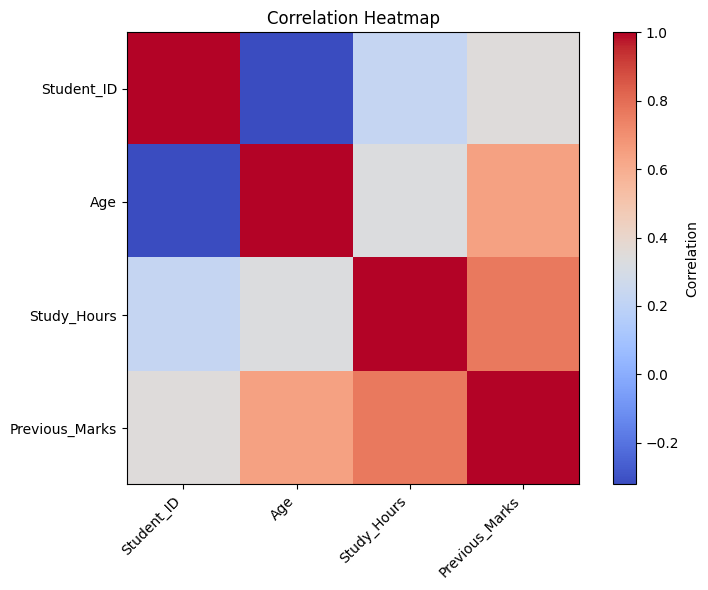

In [ ]:
# Correlation Heatmap

import matplotlib.pyplot as plt

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [ ]:
#Automated Data Quality Summary

print("=" * 50)
print(" AI DATA DETECTIVE - DATA QUALITY REPORT")
print("=" * 50)

# 1. Dataset information
print("\n DATASET INFORMATION")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# 2. Missing values
print("\n MISSING VALUES")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 3. Duplicate rows
print("\n DUPLICATE ROWS")
print("Total Duplicate Rows:", df.duplicated().sum())

# 4. Duplicate IDs
print("\n DUPLICATE STUDENT IDs")
duplicate_ids = df[df["Student_ID"].duplicated(keep=False)]

if len(duplicate_ids) > 0:
    print("Duplicate IDs Found:")
    print(duplicate_ids["Student_ID"].unique())
else:
    print("No Duplicate IDs Found")

# 5. Data types
print("\n DATA TYPES")
print(df.dtypes)

# 6. Class distribution
print("\n CLASS DISTRIBUTION")
print(df["Placement"].value_counts())

print("\n" + "=" * 50)
print("DATA QUALITY SCAN COMPLETED")
print("=" * 50)

 AI DATA DETECTIVE - DATA QUALITY REPORT

 DATASET INFORMATION
Rows: 12
Columns: 6

 MISSING VALUES
Age               1
Study_Hours       1
Attendance        1
Previous_Marks    2
dtype: int64

 DUPLICATE ROWS
Total Duplicate Rows: 1

 DUPLICATE STUDENT IDs
Duplicate IDs Found:
[107]

 DATA TYPES
Student_ID          int64
Age               float64
Study_Hours       float64
Attendance         object
Previous_Marks    float64
Placement          object
dtype: object

 CLASS DISTRIBUTION
Placement
Yes    8
No     4
Name: count, dtype: int64

DATA QUALITY SCAN COMPLETED


In [ ]:
# Clean Attendance Column

print("Cleaning Attendance Column...")

# Convert Attendance to numeric
df["Attendance"] = pd.to_numeric(
    df["Attendance"],
    errors="coerce"
)

print("\n Attendance converted to numeric!")

print("\nUpdated Data Types:")
print(df.dtypes)

print("\n Missing Values After Conversion:")
print(df["Attendance"].isnull().sum())

Cleaning Attendance Column...

 Attendance converted to numeric!

Updated Data Types:
Student_ID          int64
Age               float64
Study_Hours       float64
Attendance        float64
Previous_Marks    float64
Placement          object
dtype: object

 Missing Values After Conversion:
2


In [ ]:
# Handle Missing Numerical Values

print(" Handling Missing Numerical Values...\n")

numeric_columns = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Previous_Marks"
]

for column in numeric_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

    print(f" {column} missing values filled with median:", median_value)

print("\n Remaining Missing Values:")
print(df.isnull().sum())

 Handling Missing Numerical Values...

 Age missing values filled with median: 20.0
 Study_Hours missing values filled with median: 5.0
 Attendance missing values filled with median: 88.5
 Previous_Marks missing values filled with median: 84.5

 Remaining Missing Values:
Student_ID        0
Age               0
Study_Hours       0
Attendance        0
Previous_Marks    0
Placement         0
dtype: int64


In [ ]:
#  Remove Duplicate Rows

print(" Duplicate rows before cleaning:",
      df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().copy()

print("\n Duplicate rows removed!")

print(" Duplicate rows after cleaning:",
      df.duplicated().sum())

print("\n Updated Dataset Shape:", df.shape)

 Duplicate rows before cleaning: 1

 Duplicate rows removed!
 Duplicate rows after cleaning: 0

 Updated Dataset Shape: (11, 6)


In [ ]:
#  Check Duplicate Student IDs

print("Checking Duplicate Student IDs...\n")

duplicate_ids = df[
    df["Student_ID"].duplicated(keep=False)
]

if duplicate_ids.empty:
    print("No duplicate Student IDs found!")
else:
    print(" Duplicate Student IDs found:")
    display(duplicate_ids)

Checking Duplicate Student IDs...

No duplicate Student IDs found!


In [ ]:
#  Save Cleaned Dataset

cleaned_file = "cleaned_dataset.csv"

df.to_csv(cleaned_file, index=False)

print(" Cleaned dataset saved successfully!")
print(" File name:", cleaned_file)

 Cleaned dataset saved successfully!
 File name: cleaned_dataset.csv


In [ ]:
# Download Cleaned Dataset

from google.colab import files

files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Before vs After Cleaning Comparison

print("=" * 55)
print(" BEFORE vs AFTER DATA QUALITY COMPARISON")
print("=" * 55)

print("\nBEFORE CLEANING")
print("Rows:", 12)
print("Columns:", 6)
print("Missing Values:", 5)
print("Duplicate Rows:", 1)

print("\n AFTER CLEANING")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "=" * 55)
print(" COMPARISON COMPLETED")
print("=" * 55)

 BEFORE vs AFTER DATA QUALITY COMPARISON

BEFORE CLEANING
Rows: 12
Columns: 6
Missing Values: 5
Duplicate Rows: 1

 AFTER CLEANING
Rows: 11
Columns: 6
Missing Values: 0
Duplicate Rows: 0

 COMPARISON COMPLETED


In [ ]:
# Calculate Data Quality Score

print(" Calculating Data Quality Score...\n")

# Total possible checks
total_checks = 4

passed_checks = 0

# Check 1: Missing values
if df.isnull().sum().sum() == 0:
    passed_checks += 1
    print(" Missing Value Check: PASS")
else:
    print(" Missing Value Check: FAIL")

# Check 2: Duplicate rows
if df.duplicated().sum() == 0:
    passed_checks += 1
    print(" Duplicate Row Check: PASS")
else:
    print(" Duplicate Row Check: FAIL")

# Check 3: Duplicate Student IDs
if df["Student_ID"].duplicated().sum() == 0:
    passed_checks += 1
    print(" Duplicate ID Check: PASS")
else:
    print(" Duplicate ID Check: FAIL")

# Check 4: Numeric data types
numeric_check = all(
    pd.api.types.is_numeric_dtype(df[column])
    for column in ["Age", "Study_Hours",
                   "Attendance", "Previous_Marks"]
)

if numeric_check:
    passed_checks += 1
    print(" Data Type Check: PASS")
else:
    print(" Data Type Check: FAIL")

# Calculate score
quality_score = (passed_checks / total_checks) * 100

print("\n" + "=" * 40)
print(" DATA QUALITY SCORE:", quality_score, "/ 100")
print("=" * 40)

 Calculating Data Quality Score...

 Missing Value Check: PASS
 Duplicate Row Check: PASS
 Duplicate ID Check: PASS
 Data Type Check: PASS

 DATA QUALITY SCORE: 100.0 / 100


In [ ]:
#  Automated Data Quality Report

report = {
    "Dataset Rows": df.shape[0],
    "Dataset Columns": df.shape[1],
    "Missing Values": int(df.isnull().sum().sum()),
    "Duplicate Rows": int(df.duplicated().sum()),
    "Duplicate Student IDs": int(df["Student_ID"].duplicated().sum()),
    "Data Quality Score": quality_score
}

print("=" * 50)
print(" AI DATA DETECTIVE REPORT")
print("=" * 50)

for key, value in report.items():
    print(f"{key}: {value}")

print("=" * 50)
print(" Report Generated Successfully!")

 AI DATA DETECTIVE REPORT
Dataset Rows: 11
Dataset Columns: 6
Missing Values: 0
Duplicate Rows: 0
Duplicate Student IDs: 0
Data Quality Score: 100.0
 Report Generated Successfully!


In [ ]:
#Prepare Features and Target

print(" Preparing Data for Machine Learning...\n")

# Features
X = df.drop("Placement", axis=1)

# Target
y = df["Placement"]

print(" Features (X):")
print(X.columns.tolist())

print("\n Target (y):")
print(y.name)

print("\n Feature Shape:", X.shape)
print(" Target Shape:", y.shape)

 Preparing Data for Machine Learning...

 Features (X):
['Student_ID', 'Age', 'Study_Hours', 'Attendance', 'Previous_Marks']

 Target (y):
Placement

 Feature Shape: (11, 5)
 Target Shape: (11,)


In [ ]:
# Remove ID and Encode Target

# Remove identifier column
X = df.drop(["Placement", "Student_ID"], axis=1)

# Convert target into numeric values
y = df["Placement"].map({
    "No": 0,
    "Yes": 1
})

print(" Final Features:")
print(X.columns.tolist())

print("\n Encoded Target:")
print(y.value_counts().sort_index())

print("\n Feature Shape:", X.shape)
print(" Target Shape:", y.shape)

 Final Features:
['Age', 'Study_Hours', 'Attendance', 'Previous_Marks']

 Encoded Target:
Placement
0    3
1    8
Name: count, dtype: int64

 Feature Shape: (11, 4)
 Target Shape: (11,)


In [ ]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(" Training Data Shape:")
print(X_train.shape)

print("\n Testing Data Shape:")
print(X_test.shape)

print("\n Training Target Shape:")
print(y_train.shape)

print("\n Testing Target Shape:")
print(y_test.shape)

 Training Data Shape:
(8, 4)

 Testing Data Shape:
(3, 4)

 Training Target Shape:
(8,)

 Testing Target Shape:
(3,)


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature scaling completed!")

print("\n Scaled Training Data Shape:",
      X_train_scaled.shape)

print(" Scaled Testing Data Shape:",
      X_test_scaled.shape)

 Feature scaling completed!

 Scaled Training Data Shape: (8, 4)
 Scaled Testing Data Shape: (3, 4)


In [ ]:
#Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42)

model_lr.fit(X_train_scaled, y_train)

print(" Logistic Regression model trained successfully!")

 Logistic Regression model trained successfully!


In [ ]:
# Make Predictions

y_pred = model_lr.predict(X_test_scaled)

print(" Predictions:")
print(y_pred)

print("\n Actual Values:")
print(y_test.to_numpy())

 Predictions:
[1 1 1]

 Actual Values:
[0 1 1]


In [ ]:
#Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(" MODEL EVALUATION RESULTS")
print("=" * 35)

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")

 MODEL EVALUATION RESULTS
Accuracy  : 0.67
Precision : 0.67
Recall    : 1.00
F1-Score  : 0.80


 Confusion Matrix:
[[0 1]
 [0 2]]


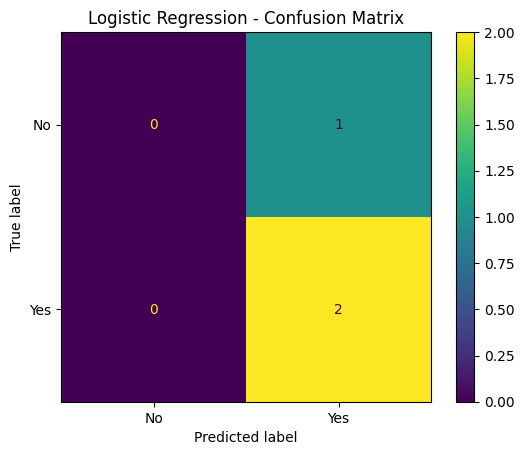

In [ ]:
#  Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(" Confusion Matrix:")
print(cm)

# Display confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

display.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
#  Train Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

model_dt.fit(X_train, y_train)

print(" Decision Tree model trained successfully!")

 Decision Tree model trained successfully!


In [ ]:
#  Decision Tree Prediction and Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Make predictions
y_pred_dt = model_dt.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

print(" DECISION TREE RESULTS")
print("=" * 35)

print(f"Accuracy  : {accuracy_dt:.2f}")
print(f"Precision : {precision_dt:.2f}")
print(f"Recall    : {recall_dt:.2f}")
print(f"F1-Score  : {f1_dt:.2f}")

 DECISION TREE RESULTS
Accuracy  : 0.67
Precision : 0.67
Recall    : 1.00
F1-Score  : 0.80


In [ ]:
#  Model Comparison - Fixed

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, accuracy_dt],
    "Precision": [precision, precision_dt],
    "Recall": [recall, recall_dt],
    "F1-Score": [f1, f1_dt]
})

print(" MODEL COMPARISON")
print("=" * 50)

print(comparison.round(2).to_string(index=False))

print("\n Model comparison completed successfully!")

 MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression      0.67       0.67     1.0       0.8
      Decision Tree      0.67       0.67     1.0       0.8

 Model comparison completed successfully!


In [ ]:
#  Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score

print(" Starting Cross-Validation...")
print("=" * 50)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Logistic Regression Cross-Validation
lr_scores = cross_val_score(
    model_lr,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n Logistic Regression")
print("CV Scores:", lr_scores)
print("Mean Accuracy:", lr_scores.mean().round(2))

# Decision Tree Cross-Validation
dt_scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n Decision Tree")
print("CV Scores:", dt_scores)
print("Mean Accuracy:", dt_scores.mean().round(2))

print("\n Cross-Validation Completed!")

 Starting Cross-Validation...

 Logistic Regression
CV Scores: [0.5        0.75       0.66666667]
Mean Accuracy: 0.64

 Decision Tree
CV Scores: [0.75       0.75       0.66666667]
Mean Accuracy: 0.72

 Cross-Validation Completed!


In [ ]:
# Model Diagnosis - Overfitting Detection

print(" MODEL DOCTOR - OVERFITTING CHECK")
print("=" * 50)

# Logistic Regression
lr_train_accuracy = model_lr.score(X_train_scaled, y_train)
lr_test_accuracy = model_lr.score(X_test_scaled, y_test)

print("\nLogistic Regression")
print("Training Accuracy:", round(lr_train_accuracy, 2))
print("Testing Accuracy :", round(lr_test_accuracy, 2))

lr_difference = lr_train_accuracy - lr_test_accuracy

print("Accuracy Difference:", round(lr_difference, 2))

if lr_difference > 0.20:
    print("Possible Overfitting Detected")
else:
    print(" No Major Overfitting Detected")


# Decision Tree
dt_train_accuracy = model_dt.score(X_train, y_train)
dt_test_accuracy = model_dt.score(X_test, y_test)

print("\n Decision Tree")
print("Training Accuracy:", round(dt_train_accuracy, 2))
print("Testing Accuracy :", round(dt_test_accuracy, 2))

dt_difference = dt_train_accuracy - dt_test_accuracy

print("Accuracy Difference:", round(dt_difference, 2))

if dt_difference > 0.20:
    print(" Possible Overfitting Detected")
else:
    print(" No Major Overfitting Detected")

print("\n" + "=" * 50)
print("Model Diagnosis Completed!")

 MODEL DOCTOR - OVERFITTING CHECK

Logistic Regression
Training Accuracy: 1.0
Testing Accuracy : 0.67
Accuracy Difference: 0.33
Possible Overfitting Detected

 Decision Tree
Training Accuracy: 1.0
Testing Accuracy : 0.67
Accuracy Difference: 0.33
 Possible Overfitting Detected

Model Diagnosis Completed!


 FEATURE IMPORTANCE ANALYSIS

 Feature Importance:
       Feature  Importance
    Attendance         1.0
           Age         0.0
   Study_Hours         0.0
Previous_Marks         0.0

 Feature importance analysis completed!


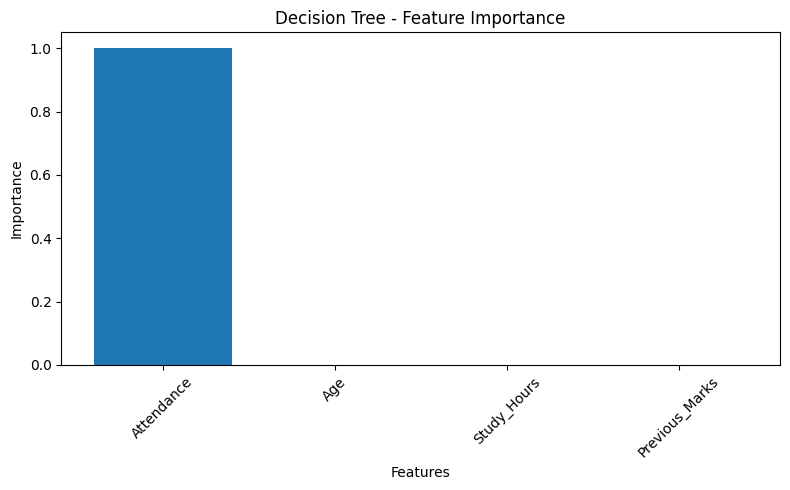

In [ ]:
# Feature Importance Analysis

import pandas as pd
import matplotlib.pyplot as plt

print(" FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get feature importance from Decision Tree
feature_importance = model_dt.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n Feature Importance:")
print(importance_df.to_string(index=False))

print("\n Feature importance analysis completed!")

#Feature Importance Chart

plt.figure(figsize=(8, 5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree - Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Automated Model Doctor Diagnosis

print(" AI MODEL DOCTOR")
print("=" * 60)

def diagnose_model(model_name, train_accuracy, test_accuracy, cv_accuracy):

    difference = train_accuracy - test_accuracy

    print(f"\n Model: {model_name}")
    print("-" * 50)

    print("Training Accuracy :", round(train_accuracy, 2))
    print("Testing Accuracy  :", round(test_accuracy, 2))
    print("Cross-Validation  :", round(cv_accuracy, 2))
    print("Train-Test Gap    :", round(difference, 2))

    print("\n Diagnosis:")

    if difference > 0.20:
        print(" Possible Overfitting")

        print("\n Suggestions:")
        print("- Reduce model complexity")
        print("- Collect more training data")
        print("- Apply cross-validation")
        print("- Try regularization")

    elif test_accuracy < 0.60:
        print(" Low Testing Performance")

        print("\n Suggestions:")
        print("- Improve data quality")
        print("- Add useful features")
        print("- Try another ML algorithm")
        print("- Check class imbalance")

    else:
        print(" Model Performance Looks Stable")

        print("\n Suggestions:")
        print("- Continue monitoring performance")
        print("- Test with new data")
        print("- Compare with other models")


# Logistic Regression Diagnosis
diagnose_model(
    "Logistic Regression",
    lr_train_accuracy,
    lr_test_accuracy,
    lr_scores.mean()
)


# Decision Tree Diagnosis
diagnose_model(
    "Decision Tree",
    dt_train_accuracy,
    dt_test_accuracy,
    dt_scores.mean()
)

print("\n" + "=" * 60)
print(" MODEL DOCTOR DIAGNOSIS COMPLETED!")

 AI MODEL DOCTOR

 Model: Logistic Regression
--------------------------------------------------
Training Accuracy : 1.0
Testing Accuracy  : 0.67
Cross-Validation  : 0.64
Train-Test Gap    : 0.33

 Diagnosis:
 Possible Overfitting

 Suggestions:
- Reduce model complexity
- Collect more training data
- Apply cross-validation
- Try regularization

 Model: Decision Tree
--------------------------------------------------
Training Accuracy : 1.0
Testing Accuracy  : 0.67
Cross-Validation  : 0.72
Train-Test Gap    : 0.33

 Diagnosis:
 Possible Overfitting

 Suggestions:
- Reduce model complexity
- Collect more training data
- Apply cross-validation
- Try regularization

 MODEL DOCTOR DIAGNOSIS COMPLETED!


 MODEL PERFORMANCE VISUALIZATION


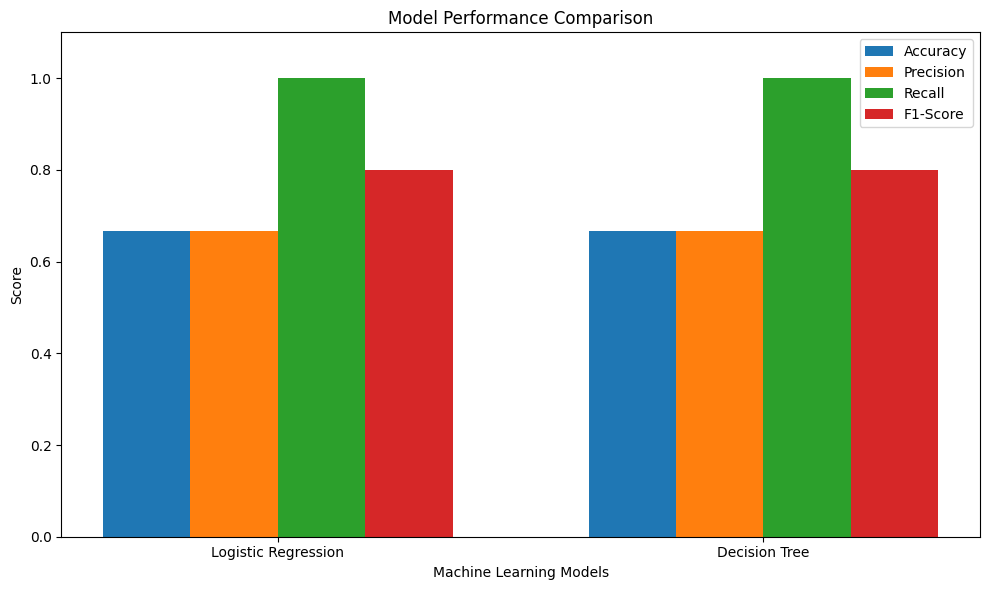

 Performance chart generated successfully!


In [ ]:
#  Model Performance Visualization

import matplotlib.pyplot as plt
import numpy as np

print(" MODEL PERFORMANCE VISUALIZATION")
print("=" * 50)

models = ["Logistic Regression", "Decision Tree"]

accuracy_values = [accuracy, accuracy_dt]
precision_values = [precision, precision_dt]
recall_values = [recall, recall_dt]
f1_values = [f1, f1_dt]

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(10, 6))

plt.bar(
    x - 1.5 * width,
    accuracy_values,
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x + 0.5 * width,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + 1.5 * width,
    f1_values,
    width,
    label="F1-Score"
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.xticks(x, models)
plt.ylim(0, 1.1)

plt.legend()
plt.tight_layout()
plt.show()

print(" Performance chart generated successfully!")

In [ ]:
# Automated Model Evaluation Summary - Fixed

evaluation_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Test Accuracy": [
        accuracy,
        accuracy_dt
    ],
    "Precision": [
        precision,
        precision_dt
    ],
    "Recall": [
        recall,
        recall_dt
    ],
    "F1-Score": [
        f1,
        f1_dt
    ],
    "CV Mean Accuracy": [
        lr_scores.mean(),
        dt_scores.mean()
    ],
    "Train Accuracy": [
        lr_train_accuracy,
        dt_train_accuracy
    ]
})

print(" AI MODEL DOCTOR - EVALUATION SUMMARY")
print("=" * 65)

print(evaluation_summary.round(2).to_string(index=False))

print("\n" + "=" * 65)
print(" AUTOMATED EVALUATION SUMMARY GENERATED!")

 AI MODEL DOCTOR - EVALUATION SUMMARY
              Model  Test Accuracy  Precision  Recall  F1-Score  CV Mean Accuracy  Train Accuracy
Logistic Regression           0.67       0.67     1.0       0.8              0.64             1.0
      Decision Tree           0.67       0.67     1.0       0.8              0.72             1.0

 AUTOMATED EVALUATION SUMMARY GENERATED!


In [ ]:
# New Student Prediction

print("NEW STUDENT PREDICTION")
print("=" * 50)

# New student details
new_student = pd.DataFrame({
    "Age": [21],
    "Study_Hours": [6],
    "Attendance": [90],
    "Previous_Marks": [85]
})

print("\n New Student Data:")
print(new_student.to_string(index=False))

# Scale the new data
new_student_scaled = scaler.transform(new_student)

# Make prediction
prediction = model_lr.predict(new_student_scaled)

# Convert prediction to label
if prediction[0] == 1:
    result = "Yes"
else:
    result = "No"

print("\n Predicted Placement:", result)

print("\n" + "=" * 50)
print("Prediction Completed!")

NEW STUDENT PREDICTION

 New Student Data:
 Age  Study_Hours  Attendance  Previous_Marks
  21            6          90              85

 Predicted Placement: Yes

Prediction Completed!


In [ ]:
#  Prediction Probability

print(" AI PREDICTION ANALYSIS")
print("=" * 55)

# Get prediction probability
prediction_probability = model_lr.predict_proba(
    new_student_scaled
)

no_probability = prediction_probability[0][0]
yes_probability = prediction_probability[0][1]

# Final prediction
prediction = model_lr.predict(new_student_scaled)

if prediction[0] == 1:
    result = "Yes"
    confidence = yes_probability
else:
    result = "No"
    confidence = no_probability

print("\n Student Details:")
print(new_student.to_string(index=False))

print("\n Prediction:", result)

print(
    f" Placement Probability: {yes_probability * 100:.2f}%"
)

print(
    f" Non-Placement Probability: {no_probability * 100:.2f}%"
)

print(
    f" Model Confidence for Predicted Class: "
    f"{confidence * 100:.2f}%"
)

print("\n" + "=" * 55)
print(" Prediction Probability Analysis Completed!")

 AI PREDICTION ANALYSIS

 Student Details:
 Age  Study_Hours  Attendance  Previous_Marks
  21            6          90              85

 Prediction: Yes
 Placement Probability: 92.58%
 Non-Placement Probability: 7.42%
 Model Confidence for Predicted Class: 92.58%

 Prediction Probability Analysis Completed!


In [ ]:
# Save ML Models using Joblib

import joblib
import os

print("SAVING MACHINE LEARNING MODELS")
print("=" * 55)

# Save Logistic Regression model
joblib.dump(model_lr, "logistic_regression_model.pkl")

# Save Decision Tree model
joblib.dump(model_dt, "decision_tree_model.pkl")

# Save scaler
joblib.dump(scaler, "feature_scaler.pkl")

print("Logistic Regression model saved!")
print("Decision Tree model saved!")
print("Feature scaler saved!")

print("\n Saved Files:")

for file_name in [
    "logistic_regression_model.pkl",
    "decision_tree_model.pkl",
    "feature_scaler.pkl"
]:
    print(
        f"{file_name} → "
        f"{os.path.getsize(file_name)} bytes"
    )

print("\n" + "=" * 55)
print(" All ML files saved successfully!")

SAVING MACHINE LEARNING MODELS
Logistic Regression model saved!
Decision Tree model saved!
Feature scaler saved!

 Saved Files:
logistic_regression_model.pkl → 895 bytes
decision_tree_model.pkl → 1849 bytes
feature_scaler.pkl → 1015 bytes

 All ML files saved successfully!


In [ ]:
# Load Saved Models and Test

import joblib

print(" LOADING SAVED ML MODELS")
print("=" * 55)

# Load Logistic Regression model
loaded_lr = joblib.load("logistic_regression_model.pkl")

# Load Decision Tree model
loaded_dt = joblib.load("decision_tree_model.pkl")

# Load scaler
loaded_scaler = joblib.load("feature_scaler.pkl")

print(" Logistic Regression model loaded!")
print("Decision Tree model loaded!")
print(" Feature scaler loaded!")

# Test the Loaded Logistic Regression Model

# Scale new student data using loaded scaler
new_student_scaled_loaded = loaded_scaler.transform(
    new_student
)

# Prediction using loaded model
loaded_prediction = loaded_lr.predict(
    new_student_scaled_loaded
)

# Probability
loaded_probability = loaded_lr.predict_proba(
    new_student_scaled_loaded
)

if loaded_prediction[0] == 1:
    loaded_result = "Yes"
else:
    loaded_result = "No"

print("\n LOADED MODEL PREDICTION")
print("=" * 45)

print("Predicted Placement:", loaded_result)

print(
    f"Placement Probability: "
    f"{loaded_probability[0][1] * 100:.2f}%"
)

print("\n Saved model works correctly!")

 LOADING SAVED ML MODELS
 Logistic Regression model loaded!
Decision Tree model loaded!
 Feature scaler loaded!

 LOADED MODEL PREDICTION
Predicted Placement: Yes
Placement Probability: 92.58%

 Saved model works correctly!


In [ ]:
#  Automated Complete Project Report

print(" AI DATA DETECTIVE & MODEL DOCTOR")
print("=" * 65)

# Create complete report dictionary
complete_report = {
    "Dataset Rows": int(df.shape[0]),
    "Dataset Columns": int(df.shape[1]),
    "Missing Values After Cleaning": int(df.isnull().sum().sum()),
    "Duplicate Rows After Cleaning": int(df.duplicated().sum()),
    "Data Quality Score": float(quality_score),

    "Logistic Regression Accuracy": float(accuracy),
    "Logistic Regression Precision": float(precision),
    "Logistic Regression Recall": float(recall),
    "Logistic Regression F1-Score": float(f1),
    "Logistic Regression CV Accuracy": float(lr_scores.mean()),

    "Decision Tree Accuracy": float(accuracy_dt),
    "Decision Tree Precision": float(precision_dt),
    "Decision Tree Recall": float(recall_dt),
    "Decision Tree F1-Score": float(f1_dt),
    "Decision Tree CV Accuracy": float(dt_scores.mean())
}

print("\n COMPLETE PROJECT REPORT")
print("-" * 65)

for key, value in complete_report.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

print("\n" + "=" * 65)
print("COMPLETE REPORT GENERATED SUCCESSFULLY!")

 AI DATA DETECTIVE & MODEL DOCTOR

 COMPLETE PROJECT REPORT
-----------------------------------------------------------------
Dataset Rows: 11
Dataset Columns: 6
Missing Values After Cleaning: 0
Duplicate Rows After Cleaning: 0
Data Quality Score: 100.00
Logistic Regression Accuracy: 0.67
Logistic Regression Precision: 0.67
Logistic Regression Recall: 1.00
Logistic Regression F1-Score: 0.80
Logistic Regression CV Accuracy: 0.64
Decision Tree Accuracy: 0.67
Decision Tree Precision: 0.67
Decision Tree Recall: 1.00
Decision Tree F1-Score: 0.80
Decision Tree CV Accuracy: 0.72

COMPLETE REPORT GENERATED SUCCESSFULLY!


In [ ]:
#Save Complete Report as CSV

report_df = pd.DataFrame(
    list(complete_report.items()),
    columns=["Metric", "Value"]
)

report_file = "AI_Data_Detective_Model_Doctor_Report.csv"

report_df.to_csv(
    report_file,
    index=False
)

print(" REPORT SAVED SUCCESSFULLY!")
print("=" * 55)

print("File Name:", report_file)
print("Number of Report Metrics:", len(report_df))

print("\n Report Preview:")
print(report_df.to_string(index=False))

print("\n CSV Report Created Successfully!")

# Download Automated Report

from google.colab import files

files.download(report_file)

 REPORT SAVED SUCCESSFULLY!
File Name: AI_Data_Detective_Model_Doctor_Report.csv
Number of Report Metrics: 15

 Report Preview:
                         Metric      Value
                   Dataset Rows  11.000000
                Dataset Columns   6.000000
  Missing Values After Cleaning   0.000000
  Duplicate Rows After Cleaning   0.000000
             Data Quality Score 100.000000
   Logistic Regression Accuracy   0.666667
  Logistic Regression Precision   0.666667
     Logistic Regression Recall   1.000000
   Logistic Regression F1-Score   0.800000
Logistic Regression CV Accuracy   0.638889
         Decision Tree Accuracy   0.666667
        Decision Tree Precision   0.666667
           Decision Tree Recall   1.000000
         Decision Tree F1-Score   0.800000
      Decision Tree CV Accuracy   0.722222

 CSV Report Created Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#  Install Streamlit

!pip install -q streamlit

print(" Streamlit installed successfully!")

#  Create Streamlit App

app_code = '''
import streamlit as st

st.set_page_config(
    page_title="AI Data Detective & Model Doctor",
    page_icon="",
    layout="wide"
)

st.title(" AI Data Detective & Model Doctor")

st.write(
    "An automated Data Quality Analysis and Machine Learning "
    "Model Diagnosis System"
)

st.success("Application Started Successfully!")

st.header(" Data Detective")

st.write(
    "Upload a CSV dataset to analyze data quality, "
    "missing values, duplicates and other issues."
)

uploaded_file = st.file_uploader(
    "Upload CSV Dataset",
    type=["csv"]
)

if uploaded_file is not None:
    st.success("CSV file uploaded successfully!")
'''

with open("app.py", "w") as file:
    file.write(app_code)

print(" app.py created successfully!")

# Check app.py

import os

print(" app.py exists:", os.path.exists("app.py"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 54.4 MB/s eta 0:00:00
 Streamlit installed successfully!
 app.py created successfully!
 app.py exists: True


In [ ]:
#  Run Streamlit App

!streamlit run app.py > streamlit_logs.txt 2>&1 &

# Check Streamlit Status

!cat streamlit_logs.txt

In [ ]:
# Install LocalTunnel

!npm install -g localtunnel

print(" LocalTunnel installed!")

#Start Streamlit

!streamlit run app.py > streamlit_logs.txt 2>&1 &

# Create Public URL

!lt --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 4s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇ LocalTunnel installed!
your url is: https://rare-meals-nail.loca.lt
^C


In [ ]:
# Stop old Streamlit process

!pkill -f streamlit || true

print(" Old Streamlit process stopped!")

# Start Streamlit again

!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    > streamlit_logs.txt 2>&1 &

# Check Streamlit logs

!cat streamlit_logs.txt